# Neural Network

In [1]:
# Packages for data processing and plotting.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import joblib
from tqdm.notebook import tqdm
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Packages to evaluate model performance.
from sklearn import metrics
from sklearn.model_selection import train_test_split, KFold, ParameterGrid

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import copy

### Load Data

In [2]:
# Load data in dataframe
train_student_data = pd.read_csv("../data/train.csv")
submission_student_data = pd.read_csv("../data/test.csv")

In [3]:
# Drop ID column (redundant)
id_data = submission_student_data["id"] # Save ID for submission
train_student_data = train_student_data.drop(columns=["id"])
submission_student_data = submission_student_data.drop(columns=["id"])  

### Preprocess

In [4]:
tabular_columns = train_student_data.select_dtypes(include=['str']).columns.tolist()
tabular_columns

['gender',
 'course',
 'internet_access',
 'sleep_quality',
 'study_method',
 'facility_rating',
 'exam_difficulty']

In [5]:
# for column in tabular_columns:
#     mapping_store = {}
#     unique_vals = train_student_data[column].unique().tolist()
#     for val in unique_vals:
#         mapping_store[val] = len(mapping_store)
#     train_student_data[column] = train_student_data[column].map(mapping_store)

oe = OrdinalEncoder()
train_student_data[tabular_columns] = oe.fit_transform(train_student_data[tabular_columns])

In [6]:
submission_student_data[tabular_columns] = oe.transform(submission_student_data[tabular_columns])

In [7]:
features = list(train_student_data.columns)
features.remove("exam_score")

X = train_student_data[features]
y = train_student_data["exam_score"]
X_submission = submission_student_data[features]

In [8]:
numeric_columns = [c for c in X.select_dtypes(include=['number']).columns if c not in tabular_columns]
numeric_columns

['age', 'study_hours', 'class_attendance', 'sleep_hours']

In [9]:
scaler = StandardScaler()
X[numeric_columns] = scaler.fit_transform(X[numeric_columns])
X_submission[numeric_columns] = scaler.transform(X_submission[numeric_columns])

In [10]:
# print("Previous Data Types:")
# print(f" - Features Training: {type(X)}")
# print(f" - Label: {type(y)}")
# print(f" - Features Submission: {type(X_submission)}")
# print()

# # Convert data to tensors.
# X_tensor = torch.tensor(X.to_numpy(), dtype=torch.float32)
# y_tensor = torch.tensor(y.to_numpy(), dtype=torch.float32).reshape(-1, 1)
# X_submission_tensor = torch.tensor(X_submission.to_numpy(), dtype=torch.float32)

# print("New Data Types:")
# print(f" - Features Training: {type(X_tensor)}")
# print(f" - Label: {type(y_tensor)}")
# print(f" - Features Submission: {type(X_submission_tensor)}")

### Train/Validation Split

In [11]:
# seed = 100
# test_size = 0.2

# X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=test_size, random_state=seed)

In [12]:
cat_cols = ['gender', 'course', 'internet_access',
            'sleep_quality', 'study_method',
            'facility_rating', 'exam_difficulty']
num_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

X_cat = torch.tensor(X[cat_cols].to_numpy(), dtype=torch.long)
X_num = torch.tensor(X[num_cols].to_numpy(), dtype=torch.float32)
y_tensor = torch.tensor(y.to_numpy(), dtype=torch.float32).reshape(-1, 1)

X_sub_cat = torch.tensor(X_submission[cat_cols].to_numpy(), dtype=torch.long)
X_sub_num = torch.tensor(X_submission[num_cols].to_numpy(), dtype=torch.float32)

In [13]:
seed = 100
test_size = 0.2

dataset = TensorDataset(X_cat, X_num, y_tensor)
train_size = int((1 - test_size) * len(dataset))
test_size_n = len(dataset) - train_size

In [14]:
torch.manual_seed(seed)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size_n])

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Model Definition

In [15]:
# class StudentScoreNet(nn.Module):
#     def __init__(self):
#         super().__init__()

#         self.emb_gender = nn.Embedding(X['gender'].nunique(), 2)
#         self.embed_course = nn.Embedding(X['course'].nunique(), 4)
#         self.embed_internet_access = nn.Embedding(X['internet_access'].nunique(), 2)
#         self.sleep_quality = nn.Embedding(X['sleep_quality'].nunique(), 2)
#         self.study_method = nn.Embedding(X['study_method'].nunique(), 3)
#         self.facility_rating = nn.Embedding(X['facility_rating'].nunique(), 2)
#         self.exam_difficulty = nn.Embedding(X['exam_difficulty'].nunique(), 2)

#         # Total concat dim: (2+4+2+2+3+2+2) + 4 numeric = 21
#         self.dense = nn.Sequential(
#             nn.Linear(21, 64),
#             nn.BatchNorm1d(64),
#             nn.ReLU(),
#             nn.Dropout(0.3),

#             nn.Linear(64, 32),
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
#             nn.Dropout(0.3),

#             nn.Linear(32, 1)
#         )
    
#     def forward(self, x_cat, x_num):
#         # x_cat: (batch, 7) — integer-encoded
#         # x_num: (batch, 4) — standardized numerics

#         # Each embedding expects a 1D LongTensor, so index each column
#         embs = [
#             self.emb_gender(x_cat[:, 0]),
#             self.emb_course(x_cat[:, 1]),
#             self.emb_internet(x_cat[:, 2]),
#             self.emb_sleep_quality(x_cat[:, 3]),
#             self.emb_study_method(x_cat[:, 4]),
#             self.emb_facility(x_cat[:, 5]),
#             self.emb_exam_diff(x_cat[:, 6]),
#         ]

#         # Concatenate all embeddings + numeric features → (batch, 21)
#         x = torch.cat(embs + [x_num], dim=1)

#         return self.dense(x)


In [16]:
class StudentScoreNet(nn.Module):
    def __init__(self, cat_features, cat_dims, emb_dims, num_numeric, num_output=1, dropout=0.15):
        """
        Args:
            cat_features: list of categorical column names
                          e.g. ['gender', 'course', 'internet_access', ...]
            cat_dims:     list of ints — number of unique categories per feature
                          e.g. [3, 7, 2, 3, 5, 3, 3]
            emb_dims:     list of ints — embedding dimension per feature
                          e.g. [2, 4, 2, 2, 3, 2, 2]
            num_numeric:  int — number of numeric features (4 in our case)
            num_output:   int — output size (1 for single-target regression)
            dropout:      float — dropout rate for regularization
        """
        super().__init__()

        # Create one embedding layer per categorical feature
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_categories, emb_dim)
            for num_categories, emb_dim in zip(cat_dims, emb_dims)
        ])

        # Total input dim to dense layers = sum of all embedding dims + numeric features
        total_emb_dim = sum(emb_dims)
        concat_dim = total_emb_dim + num_numeric

        # Dense layers
        self.dense = nn.Sequential(
            nn.Linear(concat_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Dropout(dropout),

            nn.Linear(64, num_output)

        )

    def forward(self, x_cat, x_num):
        """
        Args:
            x_cat: (batch, num_cat_features) — LongTensor of label-encoded ints
            x_num: (batch, num_numeric)      — FloatTensor of standardized numerics
        Returns:
            (batch, num_output) — predicted exam score(s)
        """
        # Pass each categorical column through its embedding layer
        embs = [
            emb_layer(x_cat[:, i])
            for i, emb_layer in enumerate(self.embeddings)
        ]

        # Concatenate all embeddings + numeric features → (batch, concat_dim)
        x = torch.cat(embs + [x_num], dim=1)

        return self.dense(x)

In [17]:
cat_features = ['gender', 'course', 'internet_access',
                'sleep_quality', 'study_method',
                'facility_rating', 'exam_difficulty']

cat_dims = [3, 7, 2, 3, 5, 3, 3]
emb_dims = [2, 4, 2, 2, 3, 2, 2]
num_numeric = 4  
num_output = 1

In [18]:
model = StudentScoreNet(cat_features, cat_dims, emb_dims, num_numeric, num_output)
model

StudentScoreNet(
  (embeddings): ModuleList(
    (0): Embedding(3, 2)
    (1): Embedding(7, 4)
    (2): Embedding(2, 2)
    (3): Embedding(3, 2)
    (4): Embedding(5, 3)
    (5-6): 2 x Embedding(3, 2)
  )
  (dense): Sequential(
    (0): Linear(in_features=21, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.01)
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.01)
    (11): Dropout(p=0.15, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [19]:
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")


Total parameters: 47,816


In [20]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.best_weights = None
        self.should_stop = False

    def step(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_weights = copy.deepcopy(model.state_dict())
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

### Hyperparameter Tuning (Grid Search CV)

In [21]:
def train_evaluate_fold(X_cat_data, X_num_data, y_data, train_idx, val_idx, params,
                        cat_features, cat_dims, emb_dims, num_numeric, num_output,
                        num_epochs=30):
    """Train and evaluate a model on a single K-Fold split."""
    # Split data by fold indices
    X_cat_train, X_cat_val = X_cat_data[train_idx], X_cat_data[val_idx]
    X_num_train, X_num_val = X_num_data[train_idx], X_num_data[val_idx]
    y_train, y_val = y_data[train_idx], y_data[val_idx]

    # Create DataLoaders
    train_ds = TensorDataset(X_cat_train, X_num_train, y_train)
    val_ds = TensorDataset(X_cat_val, X_num_val, y_val)
    train_dl = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=params['batch_size'], shuffle=False)

    # Build model with current hyperparameters
    fold_model = StudentScoreNet(
        cat_features, cat_dims, emb_dims, num_numeric, num_output,
        dropout=params['dropout']
    )
    optimizer = torch.optim.Adam(
        fold_model.parameters(), lr=params['lr'], weight_decay=params['weight_decay']
    )
    criterion = nn.MSELoss()
    es = EarlyStopping(patience=5)

    epoch_bar = tqdm(range(num_epochs), desc="Epochs", leave=False)
    for epoch in epoch_bar:
        fold_model.train()
        for xc, xn, yb in train_dl:
            optimizer.zero_grad()
            loss = criterion(fold_model(xc, xn), yb)
            loss.backward()
            optimizer.step()

        fold_model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xc, xn, yb in val_dl:
                val_loss += criterion(fold_model(xc, xn), yb).item() * len(yb)
        val_loss /= len(val_ds)

        epoch_bar.set_postfix(val_loss=f"{val_loss:.4f}")

        es.step(val_loss, fold_model)
        if es.should_stop:
            fold_model.load_state_dict(es.best_weights)
            break

    # Final evaluation on validation fold
    fold_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xc, xn, yb in val_dl:
            all_preds.append(fold_model(xc, xn))
            all_labels.append(yb)

    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    return metrics.r2_score(labels, preds)

In [22]:
# Extract training data only (avoid data leakage — test set stays unseen)
train_indices = list(train_dataset.indices)
X_cat_search = X_cat[train_indices]
X_num_search = X_num[train_indices]
y_search = y_tensor[train_indices]

# Define hyperparameter grid
param_grid = {
    'lr': [1e-3, 5e-4, 1e-4],
    'dropout': [0.1, 0.2, 0.3],
    'weight_decay': [1e-5, 1e-4, 1e-3],
    'batch_size': [256, 512],
}

n_splits = 3
kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
grid = list(ParameterGrid(param_grid))

print(f"Grid Search: {len(grid)} parameter combinations × {n_splits} folds = {len(grid) * n_splits} fits\n")

results = []
for i, params in enumerate(tqdm(grid, desc="Grid Search")):
    fold_r2s = []
    for fold, (fold_train_idx, fold_val_idx) in enumerate(tqdm(kf.split(X_cat_search), total=n_splits, desc=f"[{i+1}/{len(grid)}] Folds", leave=False)):
        r2 = train_evaluate_fold(
            X_cat_search, X_num_search, y_search,
            fold_train_idx, fold_val_idx, params,
            cat_features, cat_dims, emb_dims, num_numeric, num_output,
            num_epochs=30
        )
        fold_r2s.append(r2)

    mean_r2 = np.mean(fold_r2s)
    std_r2 = np.std(fold_r2s)
    results.append({**params, 'mean_r2': mean_r2, 'std_r2': std_r2})
    tqdm.write(f"  [{i+1}/{len(grid)}] R²={mean_r2:.4f} ± {std_r2:.4f} | {params}")

Grid Search: 54 parameter combinations × 3 folds = 162 fits



Grid Search:   0%|          | 0/54 [00:00<?, ?it/s]

[1/54] Folds:   0%|          | 0/3 [00:00<?, ?it/s]

Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

...

[54/54] Folds:   0%|          | 0/3 [00:00<?, ?it/s]

Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

  [54/54] R²=0.7762 ± 0.0018 | {'batch_size': 512, 'dropout': 0.3, 'lr': 0.0001, 'weight_decay': 0.001}


In [23]:
# Compile and display results
results_df = pd.DataFrame(results).sort_values('mean_r2', ascending=False).reset_index(drop=True)
print("Top 10 configurations:")
results_df.head(10)

Top 10 configurations:


,batch_size,dropout,lr,weight_decay,mean_r2,std_r2
0,512,0.1,0.0001,0.00010,0.779358,0.001142
1,512,0.2,0.0010,0.00010,0.779352,0.001015
2,512,0.1,0.0005,0.00010,0.779347,0.000865
3,256,0.1,0.0010,0.00001,0.779314,0.001069
4,256,0.1,0.0005,0.00010,0.779309,0.001174
5,512,0.1,0.0010,0.00010,0.779303,0.000744
6,512,0.1,0.0010,0.00001,0.779256,0.001013
7,256,0.2,0.0010,0.00100,0.779229,0.001064
8,256,0.1,0.0001,0.00001,0.779214,0.001033
9,256,0.2,0.0010,0.00001,0.779171,0.001285


In [24]:
# Extract best hyperparameters
best = results_df.iloc[0]
best_lr = best['lr']
best_dropout = best['dropout']
best_weight_decay = best['weight_decay']
best_batch_size = int(best['batch_size'])

print("Best Hyperparameters:")
print(f"  Learning Rate:  {best_lr}")
print(f"  Dropout:        {best_dropout}")
print(f"  Weight Decay:   {best_weight_decay}")
print(f"  Batch Size:     {best_batch_size}")
print(f"  Mean CV R²:     {best['mean_r2']:.4f} ± {best['std_r2']:.4f}")

Best Hyperparameters:
  Learning Rate:  0.0001
  Dropout:        0.1
  Weight Decay:   0.0001
  Batch Size:     512
  Mean CV R²:     0.7794 ± 0.0011


### Train

In [25]:
# Retrain final model on train split with best hyperparameters from grid search
train_loader = DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_batch_size, shuffle=False)

model = StudentScoreNet(cat_features, cat_dims, emb_dims, num_numeric, num_output, dropout=best_dropout)
early_stopping = EarlyStopping()
optimizer = torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=best_weight_decay)
criterion = nn.MSELoss()
num_epochs = 50

train_losses = []
test_losses = []

epoch_bar = tqdm(range(num_epochs), desc="Training", unit="epoch")

for epoch in epoch_bar:
    # --- Training ---
    model.train()
    epoch_train_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
    for x_cat_batch, x_num_batch, y_batch in train_bar:
        optimizer.zero_grad()
        y_pred = model(x_cat_batch, x_num_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * len(y_batch)
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_train_loss /= len(train_dataset)
    train_losses.append(epoch_train_loss)

    # --- Evaluation ---
    model.eval()
    epoch_test_loss = 0.0
    all_preds = []
    all_labels = []
    val_bar = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]", leave=False)
    with torch.no_grad():
        for x_cat_batch, x_num_batch, y_batch in val_bar:
            y_pred = model(x_cat_batch, x_num_batch)
            loss = criterion(y_pred, y_batch)
            epoch_test_loss += loss.item() * len(y_batch)
            all_preds.append(y_pred)
            all_labels.append(y_batch)
            val_bar.set_postfix(loss=f"{loss.item():.4f}")

    epoch_test_loss /= len(test_dataset)
    test_losses.append(epoch_test_loss)

    early_stopping.step(epoch_test_loss, model)
    if early_stopping.should_stop:
        print(f"Early stopping at epoch {epoch+1}")
        model.load_state_dict(early_stopping.best_weights)
        break

    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    r2 = metrics.r2_score(labels, preds)

    epoch_bar.set_postfix(
        train_loss=f"{epoch_train_loss:.4f}",
        val_loss=f"{epoch_test_loss:.4f}",
        R2=f"{r2:.4f}"
    )

Training:   0%|          | 0/50 [00:00<?, ?epoch/s]

Epoch 1/50 [Train]:   0%|          | 0/985 [00:00<?, ?it/s]

Epoch 1/50 [Val]:   0%|          | 0/247 [00:00<?, ?it/s]

Epoch 2/50 [Train]:   0%|          | 0/985 [00:00<?, ?it/s]

Epoch 2/50 [Val]:   0%|          | 0/247 [00:00<?, ?it/s]

...

Epoch 43/50 [Train]:   0%|          | 0/985 [00:00<?, ?it/s]

Epoch 43/50 [Val]:   0%|          | 0/247 [00:00<?, ?it/s]

Epoch 44/50 [Train]:   0%|          | 0/985 [00:00<?, ?it/s]

Epoch 44/50 [Val]:   0%|          | 0/247 [00:00<?, ?it/s]

Early stopping at epoch 44


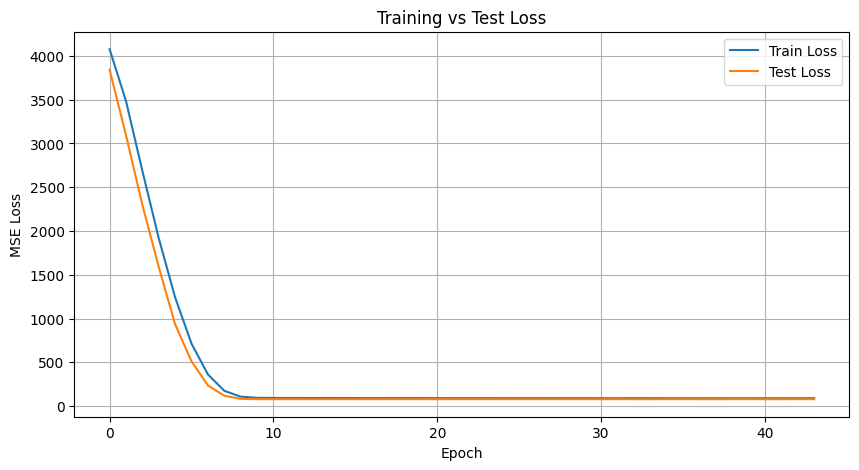

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Test Loss")
plt.legend()
plt.grid(True)
plt.show()

### Evaluate

In [27]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for x_cat_batch, x_num_batch, y_batch in test_loader:
        y_pred = model(x_cat_batch, x_num_batch)
        all_preds.append(y_pred)
        all_labels.append(y_batch)

preds = torch.cat(all_preds).numpy()
labels = torch.cat(all_labels).numpy()

r2 = metrics.r2_score(labels, preds)
rmse = np.sqrt(metrics.mean_squared_error(labels, preds))
mae = metrics.mean_absolute_error(labels, preds)

print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

R²:   0.7815
RMSE: 8.8355
MAE:  7.0562


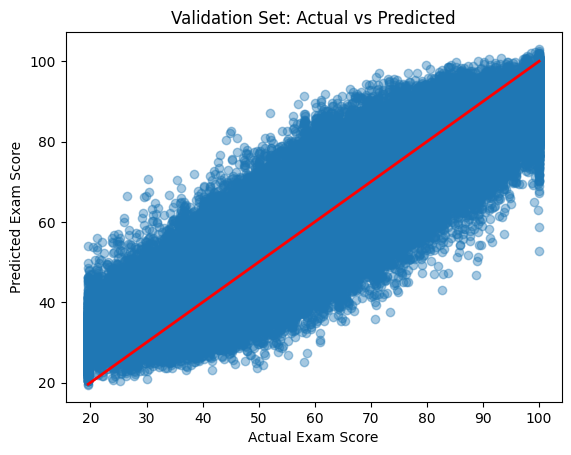

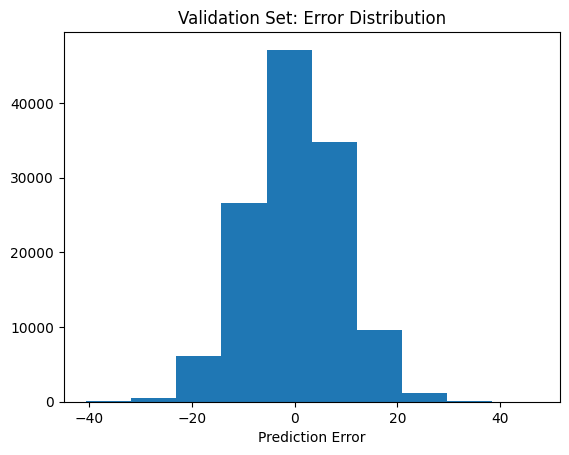

Metrics saved to ../metrics/neural_network_metrics.csv


,MAE,MSE,RMSE,R2
0,7.056183,78.065277,8.835456,0.781520


In [28]:
# Actual vs Predicted
plt.scatter(labels, preds, alpha=0.4)
plt.plot([labels.min(), labels.max()], [labels.min(), labels.max()], "r", lw=2)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Validation Set: Actual vs Predicted")
plt.show()

# Error distribution
plt.hist(labels - preds)
plt.xlabel("Prediction Error")
plt.title("Validation Set: Error Distribution")
plt.show()

# Metrics
pd.set_option("float_format", "{:f}".format)
res_metrics = pd.DataFrame({
    "MAE": [metrics.mean_absolute_error(labels, preds)],
    "MSE": [metrics.mean_squared_error(labels, preds)],
    "RMSE": [np.sqrt(metrics.mean_squared_error(labels, preds))],
    "R2": [metrics.r2_score(labels, preds)],
})
res_metrics.to_csv("../metrics/neural_network_metrics.csv", index=False)
print("Metrics saved to ../metrics/neural_network_metrics.csv")
res_metrics

### Generate Submission

In [29]:
# Generate submission predictions using contest test set
model.eval()
with torch.no_grad():
    y_submission_pred = model(X_sub_cat, X_sub_num).numpy().flatten()

submission = pd.DataFrame({
    "id": id_data,
    "exam_score": y_submission_pred
})
submission.to_csv("../submission/neural_network_linear_embedded_submission.csv", index=False)
print("Submission saved to ../submission/neural_network_linear_embedded_submission.csv")
submission

Submission saved to ../submission/neural_network_linear_embedded_submission.csv


,id,exam_score
0,630000,71.710449
1,630001,68.468079
2,630002,87.230179
3,630003,54.193321
4,630004,47.865532
...,...,...
269995,899995,61.077534
269996,899996,38.913048
269997,899997,89.916840
269998,899998,55.821541


In [30]:
# Save model
torch.save(model.state_dict(), "../models/neural_network_linear_embedded.pt")
print("Model saved to ../models/neural_network_linear_embedded.pt")

Model saved to ../models/neural_network_linear_embedded.pt
